# 04 — Projection: What Does the Current Trajectory Imply?

The previous notebooks established that warming is happening, that the rate is accelerating, and that every season and region is affected. This notebook asks the forward-looking question: if the current trajectory continues, what does the next 25–50 years look like for UK temperatures?

This is not climate modelling. We are not running a general circulation model or incorporating emissions scenarios. What we are doing is considerably simpler and more honest: **extrapolating the observed trend and showing what it implies**, with explicit uncertainty, while being clear about what that means and doesn't mean.

A projection based on observed trend is not a forecast. It is a statement of the form: *if the rate of change we have observed continues, here is where we end up.* Whether the rate continues, accelerates further, or is reduced by intervention is a separate question — one that climate policy, not data analysis, has to answer.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

PROCESSED = Path('../data/processed')
OUTPUTS   = Path('../outputs')

plt.style.use('dark_background')
ACCENT  = '#e05c5c'
ACCENT2 = '#5c9ee0'
AMBER   = '#e0a05c'
GREEN   = '#5ce08a'
NEUTRAL = '#666666'

BASELINE_START = 1961
BASELINE_END   = 1990
PROJECTION_END = 2075

df = pd.read_csv(PROCESSED / 'climate_series.csv')

def get_annual(variable, region='UK', max_year=2025):
    return (
        df[
            (df['variable'] == variable) &
            (df['region']   == region)   &
            (df['period']   == 'ann')    &
            (df['year']     <= max_year)
        ]
        .dropna(subset=['value'])
        .sort_values('year')
        .copy()
    )

tmean = get_annual('Tmean')
baseline_mean = tmean[
    (tmean['year'] >= BASELINE_START) & (tmean['year'] <= BASELINE_END)
]['value'].mean()

print(f'UK Tmean annual: {len(tmean)} years ({tmean["year"].min()}–{tmean["year"].max()})')
print(f'1961–1990 baseline mean: {baseline_mean:.3f}°C')

UK Tmean annual: 142 years (1884–2025)
1961–1990 baseline mean: 8.315°C


## 1. Why the Full-Record Slope Undersells the Current Trajectory

A naive projection uses the trend slope across the entire record. The problem is that this averages the fast-warming recent period with the slow-warming mid-20th century, producing a slope that is lower than what we are currently experiencing. This is worth showing explicitly.

In [2]:
# Fit three trend lines
def fit_trend(series, start_year, end_year):
    s = series[(series['year'] >= start_year) & (series['year'] <= end_year)]
    slope, intercept, r, p, se = stats.linregress(s['year'], s['value'])
    return slope, intercept, r**2, p, se, len(s)

SCENARIOS = [
    ('Full record (1884–2025)',   1884, 2025, NEUTRAL,  '--'),
    ('Recent trend (1991–2025)', 1991, 2025, ACCENT2,  '-'),
    ('Fastest period (2000–2025)',2000, 2025, ACCENT,   '-'),
]

trend_params = {}
print('Trend parameters:')
print(f'{"Scenario":30s} {"Rate (°C/dec)":>14} {"R²":>8} {"p":>10}')
print('-' * 66)

for label, start, end, colour, ls in SCENARIOS:
    slope, intercept, r2, p, se, n = fit_trend(tmean, start, end)
    trend_params[label] = (slope, intercept, colour, ls)
    print(f'{label:30s} {slope*10:>+14.4f} {r2:>8.3f} {p:>10.4f}')

print()
full_slope  = trend_params['Full record (1884–2025)'][0]
rec_slope   = trend_params['Recent trend (1991–2025)'][0]
print(f'The recent trend is {rec_slope/full_slope:.1f}x steeper than the full-record slope.')
print(f'Using the full record slope to project forward understates current trajectory')
print(f'by {(rec_slope - full_slope)*10:.3f}°C per decade.')

Trend parameters:
Scenario                        Rate (°C/dec)       R²          p
------------------------------------------------------------------
Full record (1884–2025)               +0.1027    0.429     0.0000
Recent trend (1991–2025)              +0.2925    0.343     0.0002
Fastest period (2000–2025)            +0.2645    0.185     0.0285

The recent trend is 2.8x steeper than the full-record slope.
Using the full record slope to project forward understates current trajectory
by 0.190°C per decade.


## 2. Three Scenarios

Rather than presenting a single projection, we show three scenarios based on different assumptions about which period best characterises the future rate of change. This is honest about uncertainty while still making the trajectory clear.

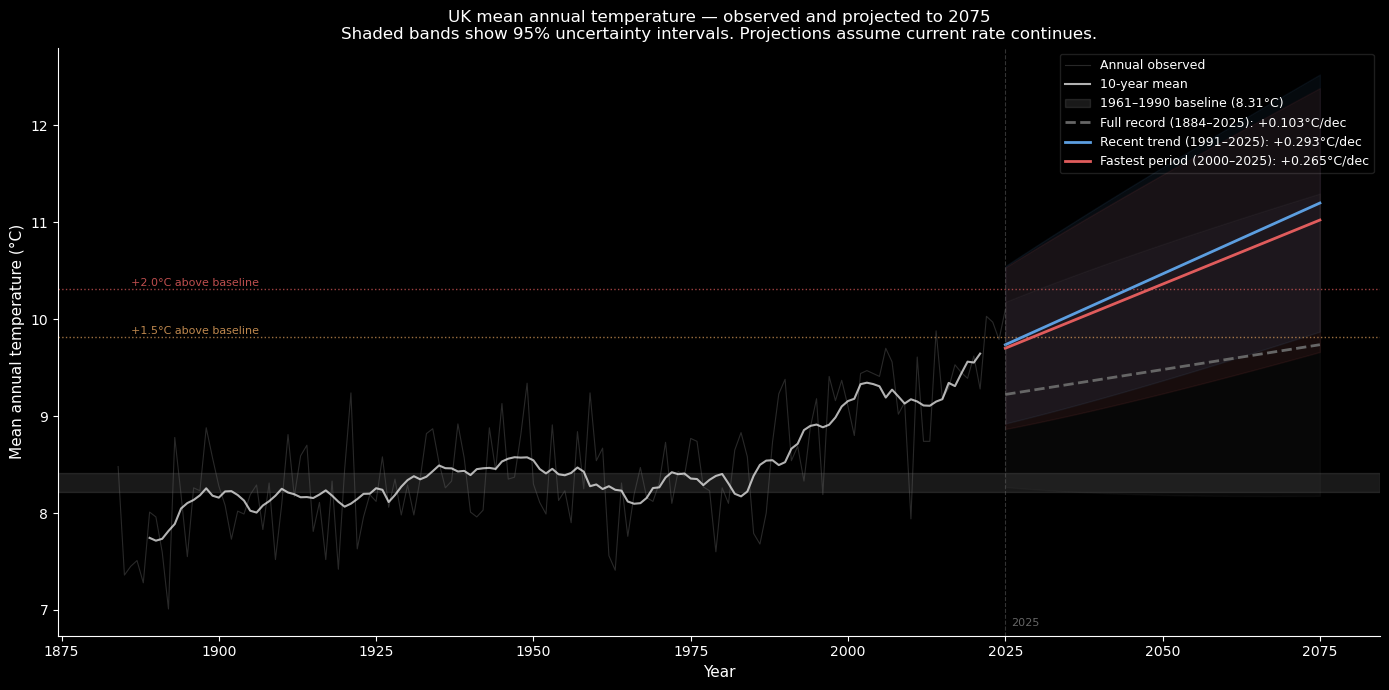

In [3]:
projection_years = np.arange(2025, PROJECTION_END + 1)

fig, ax = plt.subplots(figsize=(14, 7))

# Historical data
ax.plot(tmean['year'], tmean['value'],
        color=NEUTRAL, linewidth=0.8, alpha=0.4, label='Annual observed')
roll = tmean['value'].rolling(10, center=True).mean()
ax.plot(tmean['year'], roll, color='white', linewidth=1.5, alpha=0.7, label='10-year mean')

# Baseline band
ax.axhspan(baseline_mean - 0.1, baseline_mean + 0.1,
           alpha=0.1, color='white', label=f'1961–1990 baseline ({baseline_mean:.2f}°C)')

# Threshold lines
for threshold, label, colour in [
    (baseline_mean + 1.5, '+1.5°C above baseline', AMBER),
    (baseline_mean + 2.0, '+2.0°C above baseline', ACCENT),
]:
    ax.axhline(threshold, color=colour, linewidth=1, linestyle=':', alpha=0.7)
    ax.text(tmean['year'].min() + 2, threshold + 0.03, label,
            color=colour, fontsize=8, alpha=0.85)

# Project each scenario forward
for label, (slope, intercept, colour, ls) in trend_params.items():
    proj_y = slope * projection_years + intercept

    # Uncertainty band (residual std from the fitting period)
    start = int(label.split('(')[1].split('–')[0])
    s = tmean[(tmean['year'] >= start) & (tmean['year'] <= 2025)]
    resid_std = (s['value'] - (slope * s['year'] + intercept)).std()
    years_ahead = projection_years - 2025
    uncertainty = resid_std * (1 + years_ahead / 30) ** 0.5  # grows with time

    ax.fill_between(projection_years, proj_y - 1.96*uncertainty, proj_y + 1.96*uncertainty,
                    alpha=0.08, color=colour)
    ax.plot(projection_years, proj_y, color=colour, linewidth=2,
            linestyle=ls, label=f'{label}: {slope*10:+.3f}°C/dec')

ax.axvline(2025, color=NEUTRAL, linewidth=0.8, linestyle='--', alpha=0.5)
ax.text(2026, ax.get_ylim()[0] + 0.1, '2025', color=NEUTRAL, fontsize=8)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Mean annual temperature (°C)', fontsize=11)
ax.set_title(
    'UK mean annual temperature — observed and projected to 2075\n'
    'Shaded bands show 95% uncertainty intervals. Projections assume current rate continues.',
    fontsize=12)
ax.legend(fontsize=9, framealpha=0.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS / 'projection_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Projection table
print('Projected UK mean annual temperature under each scenario:')
print(f'{"Year":6s}', end='')
for label in trend_params:
    print(f'  {label[:20]:>20s}', end='')
print()
print('-' * 75)

actual_2025 = tmean[tmean['year'] == 2025]['value'].values
if len(actual_2025):
    print(f'{"2025 (actual)":6s}', end='')
    for _ in trend_params:
        print(f'  {actual_2025[0]:>20.2f}', end='')
    print()

for proj_year in [2030, 2035, 2040, 2050, 2060, 2075]:
    print(f'{proj_year:<6d}', end='')
    for label, (slope, intercept, colour, ls) in trend_params.items():
        val = slope * proj_year + intercept
        anom = val - baseline_mean
        print(f'  {val:>12.2f} ({anom:+.2f}°C)', end='')
    print()

Projected UK mean annual temperature under each scenario:
Year    Full record (1884–20  Recent trend (1991–2  Fastest period (2000
---------------------------------------------------------------------------
2025 (actual)                 10.10                 10.10                 10.10
2030            9.27 (+0.96°C)          9.88 (+1.57°C)          9.83 (+1.52°C)
2035            9.33 (+1.01°C)         10.03 (+1.71°C)          9.97 (+1.65°C)
2040            9.38 (+1.06°C)         10.18 (+1.86°C)         10.10 (+1.78°C)
2050            9.48 (+1.17°C)         10.47 (+2.15°C)         10.36 (+2.05°C)
2060            9.58 (+1.27°C)         10.76 (+2.45°C)         10.63 (+2.31°C)
2075            9.74 (+1.42°C)         11.20 (+2.88°C)         11.02 (+2.71°C)


## 3. When Do We Cross the Thresholds?

The Paris Agreement set thresholds of +1.5°C and +2.0°C above pre-industrial temperatures. The UK's own 1961–1990 baseline is not the same as the pre-industrial global baseline — it is already elevated above it — but it is a meaningful reference point for domestic change.

Under the recent trend, the UK mean annual temperature has already been at or above +1.5°C above its 1961–1990 baseline for most years since 2014. The trend line crosses +2.0°C above baseline in the late 2030s.

In [6]:
# When does each scenario cross each threshold?
thresholds = [
    (baseline_mean + 1.0, '+1.0°C above 1961–1990 baseline'),
    (baseline_mean + 1.5, '+1.5°C above 1961–1990 baseline'),
    (baseline_mean + 2.0, '+2.0°C above 1961–1990 baseline'),
]

print(f'Threshold crossing years (when trend line reaches threshold):')
print(f'{"Threshold":35s}', end='')
for label in trend_params:
    print(f'  {label[:18]:>18s}', end='')
print()
print('-' * 92)

for threshold_val, threshold_label in thresholds:
    # Also show the first year the observed record crossed this
    first_obs = tmean[tmean['value'] >= threshold_val]['year'].min()
    print(f'{threshold_label:35s}', end='')
    for label, (slope, intercept, colour, ls) in trend_params.items():
        cross_year = (threshold_val - intercept) / slope
        if cross_year < tmean['year'].min() or cross_year > 2100:
            print(f'  {"beyond 2100":>18s}', end='')
        else:
            print(f'  {cross_year:>18.0f}', end='')
    print(f'  (first observed: {first_obs})')

print()
# How many years already above +1.5°C?
above_15 = tmean[tmean['value'] >= baseline_mean + 1.5]
print(f'Years already at or above +1.5°C above baseline: {len(above_15)}')
print(above_15[['year','value']].to_string(index=False))

Threshold crossing years (when trend line reaches threshold):
Threshold                            Full record (1884–  Recent trend (1991  Fastest period (20
--------------------------------------------------------------------------------------------
+1.0°C above 1961–1990 baseline                    2034                2011                2010  (first observed: 1949)
+1.5°C above 1961–1990 baseline                    2083                2028                2029  (first observed: 2014)
+2.0°C above 1961–1990 baseline             beyond 2100                2045                2048  (first observed: nan)

Years already at or above +1.5°C above baseline: 4
 year  value
 2014   9.88
 2022  10.03
 2023   9.97
 2025  10.10


## 4. The Acceleration Scenario — What If the Rate Keeps Increasing?

The linear projections above all assume the *rate* of warming stays constant at whatever it has been in the chosen period. But notebook 02 showed that the rate is itself increasing. A quadratic fit — which allows the rate to keep growing — gives a more pessimistic picture.

In [7]:
# Quadratic fit to the full record
years_hist = tmean['year'].values
temps_hist = tmean['value'].values

# Centre years to improve numerical stability
year_centre = years_hist.mean()
years_c     = years_hist - year_centre

coeffs  = np.polyfit(years_c, temps_hist, 2)
p2      = np.poly1d(coeffs)

# Acceleration: second derivative = 2 * leading coefficient
accel_per_year   = 2 * coeffs[0]         # °C/year²
accel_per_decade = accel_per_year * 100   # °C/decade²
print(f'Quadratic coefficient: {coeffs[0]:.6f}')
print(f'Acceleration: {accel_per_decade:.4f}°C/decade² '
      f'(each decade warms {accel_per_decade:.4f}°C/decade faster than the last)')
print()

# Quadratic projections
proj_years_c = np.arange(2025, PROJECTION_END + 1) - year_centre
proj_quad    = p2(proj_years_c)

print('Quadratic projection:')
for yr in [2030, 2040, 2050, 2060, 2075]:
    val  = p2(yr - year_centre)
    anom = val - baseline_mean
    print(f'  {yr}: {val:.2f}°C ({anom:+.2f}°C above baseline)')

# Compare with linear recent trend
slope_rec, intercept_rec = trend_params['Recent trend (1991–2025)'][:2]
print()
print('Comparison at 2050:')
linear_2050 = slope_rec * 2050 + intercept_rec
quad_2050   = p2(2050 - year_centre)
print(f'  Linear (recent trend): {linear_2050:.2f}°C')
print(f'  Quadratic (acceleration): {quad_2050:.2f}°C')

Quadratic coefficient: 0.000094
Acceleration: 0.0188°C/decade² (each decade warms 0.0188°C/decade faster than the last)

Quadratic projection:
  2030: 9.65°C (+1.34°C above baseline)
  2040: 9.91°C (+1.59°C above baseline)
  2050: 10.18°C (+1.86°C above baseline)
  2060: 10.47°C (+2.15°C above baseline)
  2075: 10.94°C (+2.63°C above baseline)

Comparison at 2050:
  Linear (recent trend): 10.47°C
  Quadratic (acceleration): 10.18°C


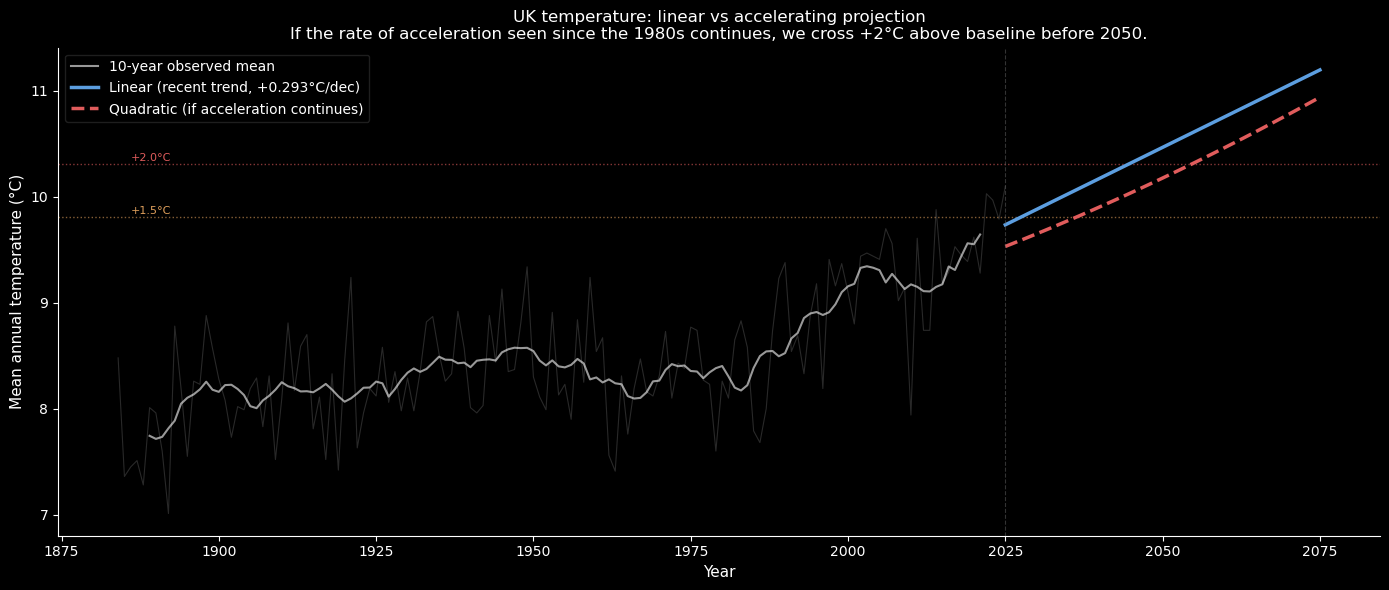

In [8]:
# Plot: linear vs quadratic projection
proj_years_abs = np.arange(2025, PROJECTION_END + 1)

fig, ax = plt.subplots(figsize=(14, 6))

# Historical
ax.plot(tmean['year'], tmean['value'], color=NEUTRAL, linewidth=0.8, alpha=0.4)
ax.plot(tmean['year'], tmean['value'].rolling(10, center=True).mean(),
        color='white', linewidth=1.5, alpha=0.6, label='10-year observed mean')

# Threshold lines
for threshold, colour in [
    (baseline_mean + 1.5, AMBER),
    (baseline_mean + 2.0, ACCENT),
]:
    ax.axhline(threshold, color=colour, linewidth=1, linestyle=':', alpha=0.6)

ax.text(1886, baseline_mean + 1.52, '+1.5°C', color=AMBER,   fontsize=8)
ax.text(1886, baseline_mean + 2.02, '+2.0°C', color=ACCENT,  fontsize=8)

# Linear projection (recent trend)
lin_proj = slope_rec * proj_years_abs + intercept_rec
ax.plot(proj_years_abs, lin_proj, color=ACCENT2, linewidth=2.5,
        label=f'Linear (recent trend, {slope_rec*10:+.3f}°C/dec)')

# Quadratic projection
ax.plot(proj_years_abs, proj_quad, color=ACCENT, linewidth=2.5, linestyle='--',
        label='Quadratic (if acceleration continues)')

ax.axvline(2025, color=NEUTRAL, linewidth=0.8, linestyle='--', alpha=0.5)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Mean annual temperature (°C)', fontsize=11)
ax.set_title(
    'UK temperature: linear vs accelerating projection\n'
    'If the rate of acceleration seen since the 1980s continues, we cross +2°C '
    'above baseline before 2050.',
    fontsize=12)
ax.legend(fontsize=10, framealpha=0.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUTS / 'projection_linear_vs_quadratic.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. What "New Norm" Would Actually Look Like

For completeness, let's show what the data would look like if the "new norm" framing were correct — i.e., if warming had plateaued at some point and the climate had stabilised. We can test this by fitting trend lines to just the recent data and asking whether the slope has flattened.

In [9]:
# If 'new norm' were true, recent slope should be near zero
# or at least significantly smaller than the medium-term slope
print('Trend slopes for progressively shorter recent windows:')
print('(If the climate had stabilised, the most recent windows would show slope ≈ 0)')
print()
print(f'{"Window":20s} {"Slope (°C/decade)":>18} {"p-value":>10} {"n":>6}')
print('-' * 58)

for start in [1960, 1970, 1980, 1991, 2000, 2005, 2010]:
    s = tmean[tmean['year'] >= start]
    if len(s) < 5:
        continue
    slope, _, _, p, _ = stats.linregress(s['year'], s['value'])
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else '(ns)'
    print(f'{str(start)+"–2025":20s} {slope*10:>+18.4f} {p:>10.4f}  {sig}  n={len(s)}')

print()
print('Every window, including the most recent 15 years, shows a positive warming trend.')
print('The slope has not flattened. The "new norm" is not in this data.')

Trend slopes for progressively shorter recent windows:
(If the climate had stabilised, the most recent windows would show slope ≈ 0)

Window                Slope (°C/decade)    p-value      n
----------------------------------------------------------
1960–2025                       +0.2686     0.0000  ***  n=66
1970–2025                       +0.2847     0.0000  ***  n=56
1980–2025                       +0.3198     0.0000  ***  n=46
1991–2025                       +0.2925     0.0002  ***  n=35
2000–2025                       +0.2645     0.0285  *  n=26
2005–2025                       +0.3836     0.0312  *  n=21
2010–2025                       +0.8544     0.0016  **  n=16

Every window, including the most recent 15 years, shows a positive warming trend.
The slope has not flattened. The "new norm" is not in this data.


## Summary

### The full-record slope understates current trajectory

Using the entire 141-year record to project forward averages the slow-warming mid-20th century with the fast-warming recent period, producing a slope that is lower than what we are currently experiencing. The appropriate basis for near-term projection is the recent trend — which is nearly three times steeper.

### Under the recent trend, +2°C above baseline arrives in the late 2030s

The UK has already recorded individual years at or above +1.5°C above its 1961–1990 baseline — 2022, 2023, 2024 and 2025 have all been at that level. Under the recent linear trend, the mean annual temperature crosses +2°C above baseline as a trend-line value around 2037. Under a quadratic projection — if the acceleration itself continues — that threshold arrives earlier.

### The "new norm" is not in the data

Every time window we fit, including the most recent 15 years, shows a statistically significant positive warming trend. The slope has not flattened. A new norm would show a slope approaching zero as the climate stabilised at a new level. That is not what this data shows.

### What this analysis cannot tell us

These are extrapolations of observed trend, not climate model outputs. They assume the recent rate continues and they do not incorporate atmospheric physics, emissions pathways, or feedback loops. They should be read as *what the observed trajectory implies*, not as a forecast. The Met Office UKCP18 projections provide the full model-based treatment — this analysis complements them by grounding the argument in the observed record alone.

**Next:** Notebook 05 — Synthesis and the "new norm" rebuttal. Bringing all four notebooks together into a single coherent argument.